In [2]:
import numpy as np
import os
import xarray as xr
import glob
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
import dask.array as da
import pickle
from scipy.stats import t
import matplotlib.ticker as ticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

In [3]:
with open('/home/annierosen16/master.pkl', 'rb') as f:
    
    master = pickle.load(f)

In [4]:
with open('/home/annierosen16/pressure.pkl', 'rb') as f:
    
    pressure = pickle.load(f)
    
with open('/home/annierosen16/sgp_latitudes.pkl', 'rb') as f:
    
    latitude = pickle.load(f)
    
with open('/home/annierosen16/sgp_longitudes.pkl', 'rb') as f:
    
    longitude = pickle.load(f)

In [5]:
# reading in ERA5 u, v, w and q

base_path = '/data/rong4/Data/ERA5/3hourly/quvw_US'

years = [str(year) for year in range(2001, 2019)]

def get_files(folder, component):

    files = glob.glob(os.path.join(base_path, folder, f"era5.{component}.*.nc"))

    filtered_files = [f for f in files if any(year in f for year in years)]
    
    return filtered_files

# Get the files for each component

u_files = get_files('u_component_of_wind', 'u_component_of_wind')

v_files = get_files('v_component_of_wind', 'v_component_of_wind')

w_files = get_files('vertical_velocity', 'vertical_velocity')

q_files = get_files('specific_humidity', 'specific_humidity')

all_files = u_files + v_files + q_files + w_files

# open all datasets at once

convergences = xr.open_mfdataset(all_files, combine='by_coords', chunks={'time': 24})

In [7]:
# filtering for correct domain and time

convvars = convergences.sel(
    
    latitude=slice(40, 29),
    
    longitude=slice(-106, -94)
)

convvars['time'] = convvars['time'] - pd.Timedelta(hours=6)

sub = convvars.where(
    
    (convvars.time.dt.hour.isin([0, 6, 12])) &
    
    (convvars.time.dt.month.isin([5, 6, 7, 8, 9])) &
    
    (convvars.time.dt.year.isin(range(2001, 2019))),
    
    drop=True
)

# Resample to daily frequency and compute the mean

daily_avg = sub.resample(time='D').mean().dropna(dim='time', how='all')

daily_avg['time'].shape

(2754,)

In [8]:
## reading in surface pressure 

# ERA5 information: surface pressure

sfc_pressure_path = '/data/rong4/Data/ERA5/3hourly/quvw_US/surface_pressure'

all_files = glob.glob(os.path.join(sfc_pressure_path, "era5.surface_pressure.*.nc"))

# Filter files for years 2001-2018 and months 5-9

filtered_files = [
    
    file for file in all_files 
    
    if 2001 <= int(os.path.basename(file).split(".")[2][:4]) <= 2018  
    
    and 5 <= int(os.path.basename(file).split(".")[2][4:]) <= 9       
]

all_sfc_p = xr.open_mfdataset(filtered_files, combine='by_coords')

all_sfc_p = all_sfc_p.sel(latitude=slice(39.0, 30.0), longitude=slice(-105.0, -95.0))

sfcp = all_sfc_p.assign_coords(time=all_sfc_p.time - pd.Timedelta(hours=6))

sfcp = sfcp.sel(time=sfcp.time[sfcp.time.dt.hour == 6])

print(sfcp['time'].shape)

# average surface pressure per gridpoint

spdf = sfcp['sp'].to_dataframe().reset_index()

spdf_mean = spdf.groupby(['latitude', 'longitude'])['sp'].mean().reset_index(name='average_sp')

(2754,)


In [9]:
def calculate_horizontal_convergence_new(u, v, q, lat, lon):
    
    R = 6371000  # Earth's radius in meters
    
    rho_water = 1000  # kg/m³
    
    seconds_to_day = 60 * 60 * 24  # conversion from seconds to days

    # Convert latitude and longitude to radians
    lat_rad = np.radians(lat)
    
    lon_rad = np.radians(lon)

    # Grid spacing (in radians)
    dphi = lat_rad[1] - lat_rad[0]      # north-south spacing
    
    dtheta = lon_rad[1] - lon_rad[0]    # east-west spacing

    # Meshgrid for lat/lon
    lon_grid, lat_grid = np.meshgrid(lon_rad, lat_rad)
    
    cos_lat = np.cos(lat_grid)

    # Grid cell dimensions

    dx = R * dtheta * cos_lat
    
    dy = R * dphi              # meridional height (constant)

    # Area of each grid cell
    grid_area = dx * dy

    # scale v by cos(latitude) for spherical divergence
    v_scaled = v * cos_lat[np.newaxis, :, :]
    
    # initialize gradient arrays
    du_dtheta = np.zeros_like(u)  # ∂u/∂λ
    
    dv_dphi = np.zeros_like(v)    # ∂(v·sinφ)/∂φ

    # Compute zonal and meridional derivatives at each pressure level
    for k in range(u.shape[0]):
        
        # Zonal derivative (longitude direction)
        du_dtheta[k, :, 1:-1] = (u[k, :, 2:] - u[k, :, :-2]) / (2 * dtheta)
        
        du_dtheta[k, :, 0] = (u[k, :, 1] - u[k, :, 0]) / dtheta
        
        du_dtheta[k, :, -1] = (u[k, :, -2] - u[k, :, -1]) / dtheta

        # Meridional derivative (latitude direction)
        
        dv_dphi[k, 1:-1, :] = (v_scaled[k, 2:, :] - v_scaled[k, :-2, :]) / (2 * dphi)
        
        dv_dphi[k, 0, :] = (v_scaled[k, 1, :] - v_scaled[k, 0, :]) / dphi
        
        dv_dphi[k, -1, :] = (v_scaled[k, -2, :] - v_scaled[k, -1, :]) / dphi

    # Spherical coordinate divergence of wind (scaled by q)
    zonal_convergence = -(q * du_dtheta) / (R * cos_lat[np.newaxis, :, :])
        
    meridional_convergence = -(q * dv_dphi) / (R * cos_lat[np.newaxis, :, :])

    # multiply by grid area for area-weighted sum
    weighted_zonal = zonal_convergence * grid_area
    
    weighted_meridional = meridional_convergence * grid_area

    # Area-weighted average convergence per level
    
    A = np.sum(grid_area)
    
    zonal_convergence = np.sum(weighted_zonal, axis=(1, 2)) / A * seconds_to_day
    
    meridional_convergence = np.sum(weighted_meridional, axis=(1, 2)) / A * seconds_to_day
    
    # Units: 1/day
    return zonal_convergence, meridional_convergence

In [10]:
# array = (time = 12 LST, levels, latitude, longitude)

# reversing latitude to be increasing, pressure should go top to bottom 

u = daily_avg['u'].load().data[:, :, ::-1, :]

print("u loaded")

v = daily_avg['v'].load().data[:, :, ::-1, :]

print("v loaded")

q = daily_avg['q'].load().data[:, :, ::-1, :] 

print("q loaded")

latitude = daily_avg['latitude'].data[::-1]

longitude = daily_avg['longitude'].data

pressure = daily_avg['level'].data * 100 # pressure needs to be Pa for advection calculation

u loaded
v loaded
q loaded


### applying to APEs vs. non-APEs to check that vertical profiles make sense

In [ ]:
# Ensure columns exist in master for storing advection profiles

master['zonal_convergence'] = None

master['meridional_convergence'] = None

for date in range(master.shape[0]):
        
    target_date = master['date'].iloc[date]  
    
    target_date = np.datetime64(target_date)

    # Find the index in daily_avg['time'].data
    
    date_idx = np.where(daily_avg['time'].data == target_date)[0][0]

    lat_idx = master['latitude'].iloc[date]
    
    lon_idx = master['longitude'].iloc[date]

    # Define the center point and half-window (in degrees)
    
    delta = 0.5
    
    lat_mask = (latitude >= (lat_idx - delta)) & (latitude <= (lat_idx + delta))
    
    lon_mask = (longitude >= (lon_idx - delta)) & (longitude <= (lon_idx + delta))

    lat_indices = np.where(lat_mask)[0]
    
    lon_indices = np.where(lon_mask)[0]

    lat_mini = latitude[lat_indices]
    
    lon_mini = longitude[lon_indices]

    # Extract mini domains for u, v, q, w
    
    u_mini = u[date_idx, :, :, :][:, lat_mask, :][:, :, lon_mask]
    
    v_mini = v[date_idx, :, :, :][:, lat_mask, :][:, :, lon_mask]
    
    q_mini = q[date_idx, :, :, :][:, lat_mask, :][:, :, lon_mask]
    
    # Compute convergence
    
    zonal_conv, merid_conv = calculate_horizontal_convergence_new(u_mini, v_mini, q_mini, lat_mini, lon_mini)
    
    # Assign results to the DataFrame
    
    master.at[date, 'zonal_convergence'] = zonal_conv
    
    master.at[date, 'meridional_convergence'] = merid_conv
    

#### start again here

In [13]:
# accounting for surface pressure so that we don't include below ground values

master_sp = master.merge(spdf_mean[['latitude', 'longitude', 'average_sp']], on=['latitude', 'longitude'], how='left')

print("master w/ sfc pressure complete")

def mask_convergence(row):
    
    underground_mask = pressure > row['average_sp']
    
    # Replace values in the convergence arrays with np.nan where the mask is True.
    
    row['zonal_convergence'] = np.where(underground_mask, np.nan, row['zonal_convergence'])
    
    row['meridional_convergence'] = np.where(underground_mask, np.nan, row['meridional_convergence'])
        
    return row

# Apply the mask to each row.

master_clean = master_sp.apply(mask_convergence, axis=1)

master w/ sfc pressure complete


In [2]:
## skip all previous code if master_clean is updated

# with open('/home/annierosen16/master_clean.pkl', 'rb') as f:
    
#     master_clean = pickle.load(f)

In [14]:
apes = master_clean[master_clean['APE']==True][['date','latitude','longitude',
                                                'zonal_convergence','meridional_convergence']].reset_index(drop=True)

nonapes = master_clean[master_clean['APE']==False][['date','latitude','longitude',
                                                   'zonal_convergence','meridional_convergence']].reset_index(drop=True)

dryapes = master_clean[master_clean['dryape']==True][['date','latitude','longitude',
                                                     'zonal_convergence','meridional_convergence']].reset_index(drop=True)

drycoupling = master_clean[master_clean['drycoupling']==True][['date','latitude','longitude',
                                                     'zonal_convergence','meridional_convergence']].reset_index(drop=True)

wetapes = master_clean[master_clean['wetape']==True][['date','latitude','longitude', 
                                                     'zonal_convergence','meridional_convergence']].reset_index(drop=True)

wetcoupling = master_clean[master_clean['wetcoupling']==True][['date','latitude','longitude', 
                                                     'zonal_convergence','meridional_convergence']].reset_index(drop=True)

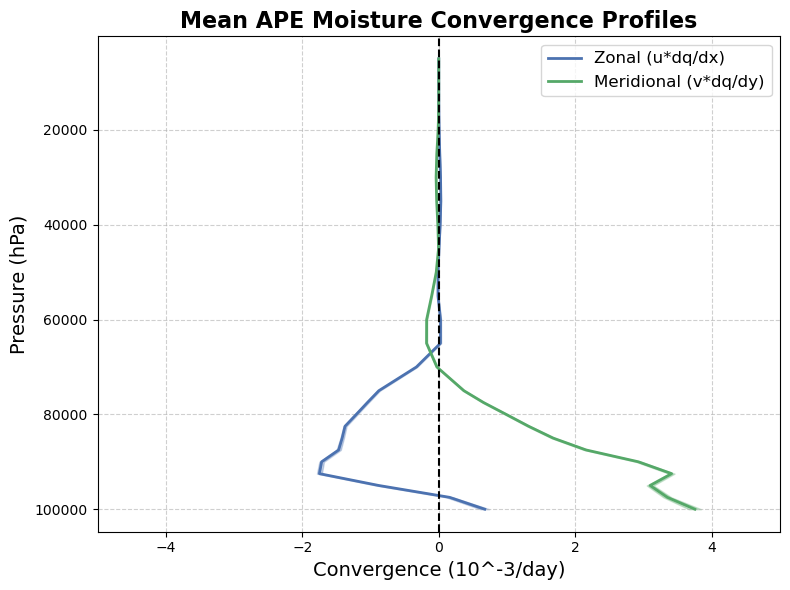

In [16]:
# Convert your lists of profiles to 2D NumPy arrays.

# Each array will have shape (n_samples, 29), where n_samples is the number of APE events.

_10_cubed_factor = 1000

cleaned_zonal_profiles = np.stack(apes['zonal_convergence'].values) * _10_cubed_factor

cleaned_meridional_profiles = np.stack(apes['meridional_convergence'].values) * _10_cubed_factor

# Compute the mean profile along the sample axis (axis=0), ignoring NaNs.

mean_zonal = np.nanmean(cleaned_zonal_profiles, axis=0) 

mean_merid = np.nanmean(cleaned_meridional_profiles, axis=0) 

# Count non-NaN values per pressure level.

n_zonal = np.sum(~np.isnan(cleaned_zonal_profiles), axis=0)

n_merid = np.sum(~np.isnan(cleaned_meridional_profiles), axis=0)

# Compute standard deviations ignoring NaNs.

std_zonal = np.nanstd(cleaned_zonal_profiles, axis=0, ddof=1)

std_merid = np.nanstd(cleaned_meridional_profiles, axis=0, ddof=1)

# Compute standard errors (be mindful that each level might have a different sample size).

se_zonal = std_zonal / np.sqrt(n_zonal)

se_merid = std_merid / np.sqrt(n_merid)

# Compute t-values per pressure level for a 95% confidence interval.
# For levels with less than 2 valid samples, we set the t-value to NaN.

t_zonal = np.array([t.ppf(0.975, df=int(n)-1) if n > 1 else np.nan for n in n_zonal])

t_merid = np.array([t.ppf(0.975, df=int(n)-1) if n > 1 else np.nan for n in n_merid])

# Compute the margin of error (CI = t * SE) for each level.

ci_zonal = t_zonal * se_zonal

ci_merid = t_merid * se_merid

# Determine xlimit based on the maximum absolute value of (mean + CI) across all profiles.
max_val = np.max([np.abs(mean_zonal + ci_zonal),
                  np.abs(mean_merid + ci_merid),
                  ])

xlimit = np.ceil(max_val * 1.1)  # add 10% margin

# Define a custom color palette.

color_zonal = '#4C72B0'    # blue

color_merid = '#55A868'    # green

plt.figure(figsize=(8, 6))

# Plot the mean profiles with uncertainty bands using fill_betweenx.
plt.plot(mean_zonal, pressure, label='Zonal (u*dq/dx)', linewidth=2, color=color_zonal)

plt.fill_betweenx(pressure, mean_zonal - ci_zonal, mean_zonal + ci_zonal,
                  color=color_zonal, alpha=0.3)

plt.plot(mean_merid, pressure, label='Meridional (v*dq/dy)', linewidth=2, color=color_merid)

plt.fill_betweenx(pressure, mean_merid - ci_merid, mean_merid + ci_merid,
                  color=color_merid, alpha=0.3)

# Invert the y-axis so that pressure decreases upward.

plt.xlim(-xlimit, xlimit)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)

# Add labels, title, legend, and grid.
plt.xlabel('Convergence (10^-3/day)', fontsize=14)

plt.ylabel('Pressure (hPa)', fontsize=14)

plt.title('Mean APE Moisture Convergence Profiles', fontsize=16, fontweight='bold')

plt.legend(fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

plt.gca().invert_yaxis()

plt.show()

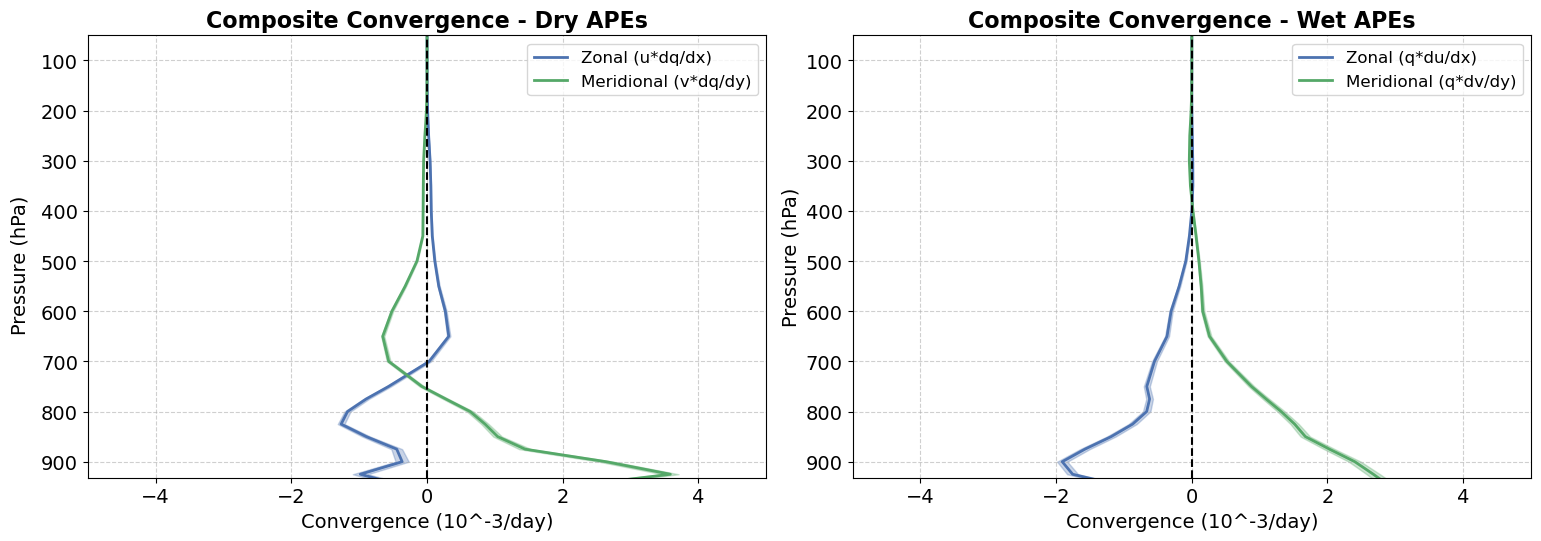

In [23]:
# -- Extract and convert profiles for dry and wet cases --

# Convert lists of profiles to 2D arrays (each of shape (n_samples, 29)).

# pressure = pressure / 100

mean_surface_pressure_hPa = master_clean['average_sp'].mean() / 100

pressure_hpa = pressure / 100 

dry_zonal = np.array(dryapes['zonal_convergence'].tolist())

dry_merid = np.array(dryapes['meridional_convergence'].tolist())

wet_zonal = np.array(wetapes['zonal_convergence'].tolist())

wet_merid = np.array(wetapes['meridional_convergence'].tolist())

# Global pressure array (assumed to be 1D with 29 levels)

# pressure = daily_avg['level'].data

# -- Function to compute mean and 95% CI using nanmean/nanstd --

def compute_stats(profiles):
    
    """
    profiles: 2D array of shape (n_samples, 29)
    Returns: mean (1D, 29) and margin of error (CI, 1D, 29)
    """
    
    _10_cubed_factor = 1000
    
    # Compute the mean ignoring NaNs.
    
    mean_profile = np.nanmean(profiles, axis=0)
    
    # Compute the number of valid (non-NaN) values per pressure level.
    n_vals = np.sum(~np.isnan(profiles), axis=0)
    
    # Compute standard error ignoring NaNs.
    se = np.nanstd(profiles, axis=0, ddof=1) / np.sqrt(n_vals)
    
    # Compute t-values per level; if less than 2 valid samples, return NaN.
    t_values = np.array([t.ppf(0.975, df=int(n)-1) if n > 1 else np.nan for n in n_vals])
    
    # Margin of error (95% confidence interval)
    ci = t_values * se
    
    return mean_profile * _10_cubed_factor, ci * _10_cubed_factor

# Compute statistics for dry apes_clean.

dry_mean_zonal, dry_ci_zonal = compute_stats(dry_zonal)

dry_mean_merid, dry_ci_merid = compute_stats(dry_merid) 

# Compute statistics for wet apes_clean.

wet_mean_zonal, wet_ci_zonal = compute_stats(wet_zonal) 

wet_mean_merid, wet_ci_merid = compute_stats(wet_merid)

# -- Determine symmetric x-axis limits for each subplot --
max_dry = np.max([np.abs(dry_mean_zonal + dry_ci_zonal),
                  np.abs(dry_mean_merid + dry_ci_merid)])
xlimit_dry = np.ceil(max_dry * 1.1)  # add 10% extra margin

max_wet = np.max([np.abs(wet_mean_zonal + wet_ci_zonal),
                  np.abs(wet_mean_merid + wet_ci_merid)])

xlimit_wet = np.ceil(max_wet * 1.1)

# -- Define a custom color palette --
color_zonal = '#4C72B0'    # blue
color_merid = '#55A868'    # green

# -- Create the figure with two subplots side by side --
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot for Dry apes_clean on ax1
ax1.plot(dry_mean_zonal, pressure_hpa, label='Zonal (u*dq/dx)', linewidth=2, color=color_zonal)
ax1.fill_betweenx(pressure_hpa, dry_mean_zonal - dry_ci_zonal, dry_mean_zonal + dry_ci_zonal,
                  color=color_zonal, alpha=0.3)

ax1.plot(dry_mean_merid, pressure_hpa, label='Meridional (v*dq/dy)', linewidth=2, color=color_merid)

ax1.fill_betweenx(pressure_hpa, dry_mean_merid - dry_ci_merid, dry_mean_merid + dry_ci_merid,
                  color=color_merid, alpha=0.3)

ax1.set_ylim(pressure.min(), mean_surface_pressure_hPa)
ax1.invert_yaxis()
ax1.set_xlim(-xlimit_dry, xlimit_dry)
ax1.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
ax1.set_xlabel('Convergence (10^-3/day)', fontsize=14)
ax1.set_title('Composite Convergence - Dry APEs', fontsize=16, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(fontsize=12)
ax1.tick_params(axis='both', labelsize=14)

# Plot for Wet apes_clean on ax2
ax2.plot(wet_mean_zonal, pressure_hpa, label='Zonal (q*du/dx)', linewidth=2, color=color_zonal)

ax2.fill_betweenx(pressure_hpa, wet_mean_zonal - wet_ci_zonal, wet_mean_zonal + wet_ci_zonal,
                  color=color_zonal, alpha=0.3)

ax2.plot(wet_mean_merid, pressure_hpa, label='Meridional (q*dv/dy)', linewidth=2, color=color_merid)

ax2.fill_betweenx(pressure_hpa, wet_mean_merid - wet_ci_merid, wet_mean_merid + wet_ci_merid,
                  color=color_merid, alpha=0.3)

ax2.set_ylim(pressure_hpa.min(), mean_surface_pressure_hPa)

ax2.invert_yaxis()

ax2.set_xlim(-xlimit_wet, xlimit_wet)

ax2.axvline(x=0, color='black', linestyle='--', linewidth=1.5)

ax2.set_xlabel('Convergence (10^-3/day)', fontsize=14)

ax2.set_title('Composite Convergence - Wet APEs', fontsize=16, fontweight='bold')

ax2.grid(True, linestyle='--', alpha=0.6)

ax2.legend(fontsize=12)

ax2.tick_params(axis='both', labelsize=14)

ax2.yaxis.set_tick_params(labelleft=True)

ax2.set_ylabel("Pressure (hPa)", fontsize=14)

# Common y-label for the figure

fig.text(0.04, 0.5, 'Pressure (hPa)', va='center', rotation='vertical', fontsize=14)

plt.tight_layout(rect=[0.05, 0.03, 1, 0.95])

plt.show()

In [ ]:
with open("/home/annierosen16/master_clean.pkl", "wb") as file:
    
    pickle.dump(master_clean, file, protocol=pickle.HIGHEST_PROTOCOL)